In [1]:
%cd ..

/home/bhchen/LearnKalmanGain


In [2]:
import torch
import matplotlib.pyplot as plt
import os
import pandas as pd

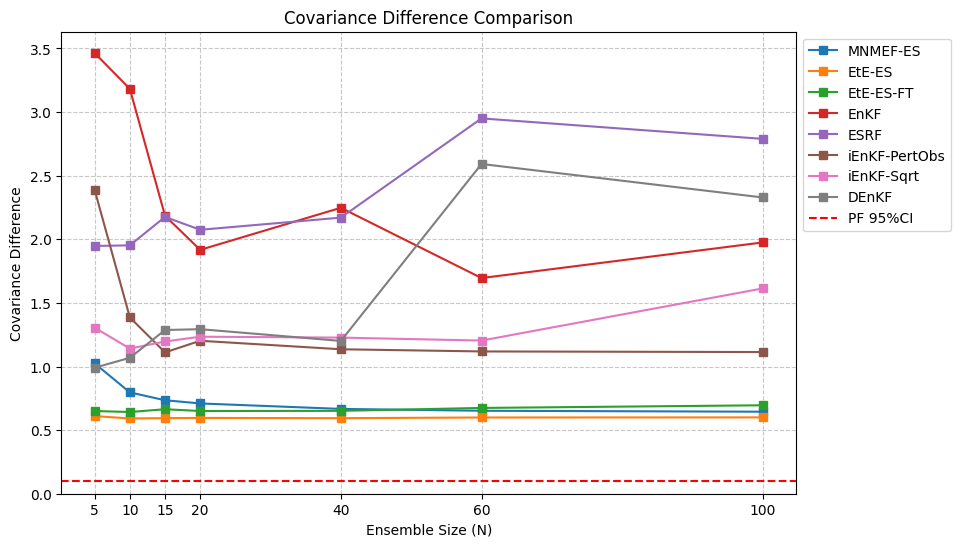

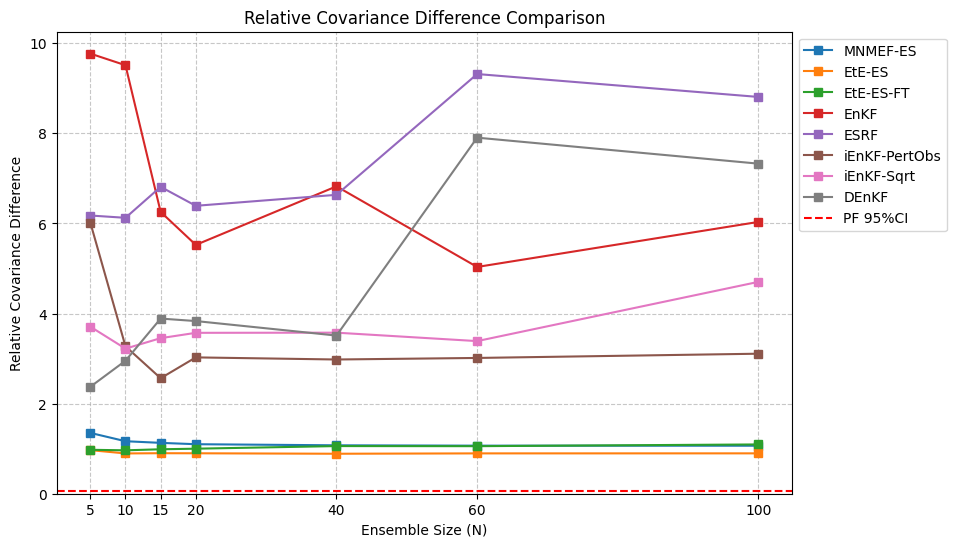

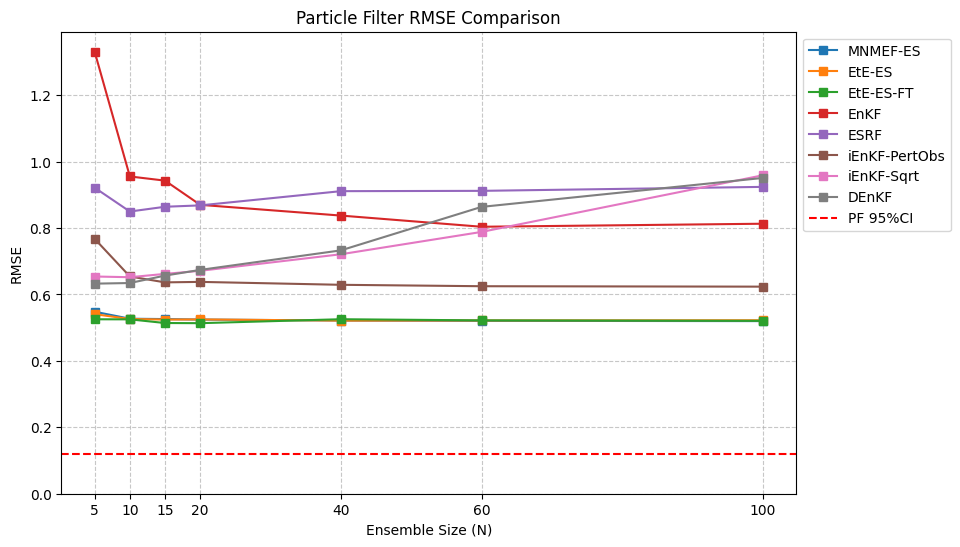

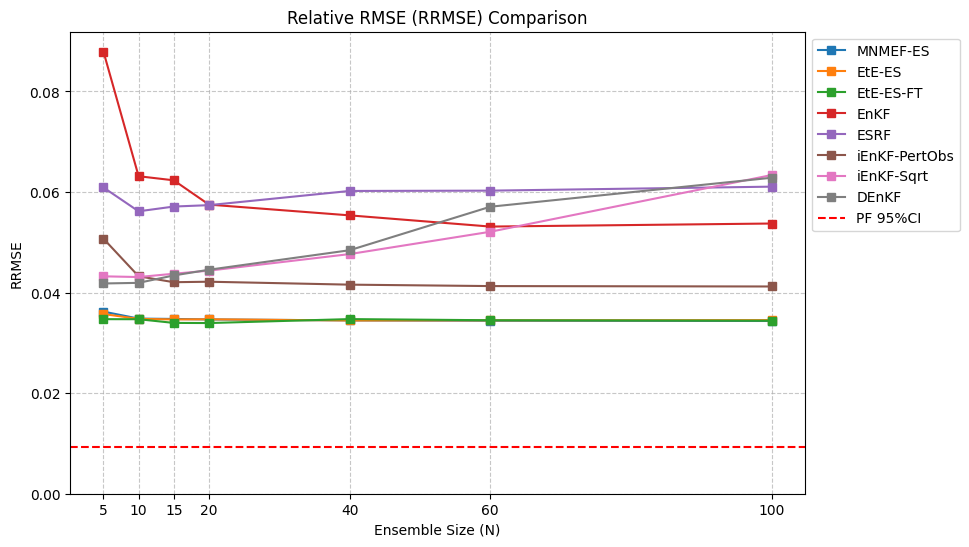

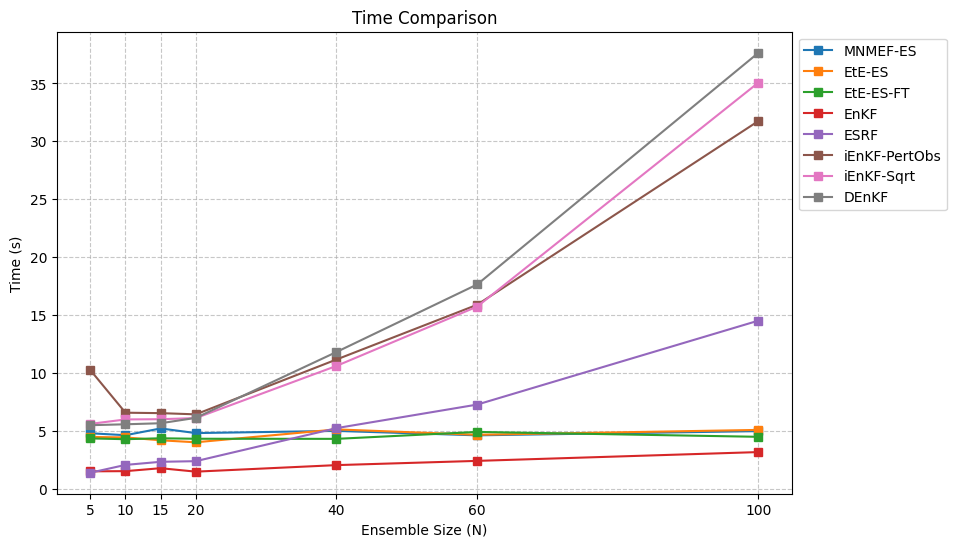

In [4]:
import os
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# --- [DATA LOADING AND PREPARATION - UNCHANGED EXCEPT NEW METRICS] ---
PF_RMSE_95CI = 0.119728
PF_Cov_Diff_95CI = 0.10073
PF_RRMSE_95CI = 0.00927624
PF_RCov_Diff_95CI = 0.0572706
ensemble_sizes = [5, 10, 15, 20, 40, 60, 100]

data_folders = [
    "2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
    # "2025-06-28_21-52lorenz63_1.0_10_60_8192_l2_joint_CorrTerms",
    "lorenz63_EtE_LRes/2025-07-09_19-08lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nst",
    "lorenz63_EtE_LRes/2025-08-08_09-55lorenz63_1.0_20_60_8192_nl2_joint_EtE-LRes_nst_tuned",
    "lorenz63_benchmarks/benchmark_lorenz63_1.0_EnKF",
    "lorenz63_benchmarks/benchmark_lorenz63_1.0_ESRF",
    "lorenz63_benchmarks/benchmark_lorenz63_1.0_iEnKS-PertObs",
    "lorenz63_benchmarks/benchmark_lorenz63_1.0_iEnKS-Sqrt",
    "lorenz63_benchmarks/benchmark_lorenz63_1.0_iEnKS-Order1",
]

method_names = [
    'MNMEF-ES',
    # 'MNMEF-L2',
    'EtE-ES',        # always nst
    'EtE-ES-FT',
    "EnKF",
    "ESRF",
    "iEnKF-PertObs",
    "iEnKF-Sqrt",
    "DEnKF",         # A deterministic formulation of the ensemble Kalman filter
]

results = {}

num_sizes = len(ensemble_sizes)
for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}.pt"
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)

        # Load file
        data = torch.load(data_file, weights_only=True)

        # Required metrics
        cov_diff = data["nn"]['cov_diff']
        pf_rmse = data["nn"]['pf_rmse']
        t = data["time"]

        # Optional relative metrics (preferred if present)
        rrmse = data["nn"].get('pf_rrmse', float('nan'))
        rcov_diff = data["nn"].get('rcov_diff', float('nan'))

        # Initialize buckets
        results.setdefault(method_name, {})
        for key in ['cov_diff', 'pf_rmse', 'rrmse', 'rcov_diff', 'time']:
            results[method_name].setdefault(key, [])

        # Append metrics
        results[method_name]['cov_diff'].append(cov_diff)
        results[method_name]['pf_rmse'].append(pf_rmse)
        results[method_name]['rrmse'].append(rrmse)
        results[method_name]['rcov_diff'].append(rcov_diff)
        results[method_name]['time'].append(t)

# --- Figure 1: Covariance Difference ---
fig1, ax1 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax1.plot(ensemble_sizes, results[key]['cov_diff'], marker='s', label=key)
ax1.axhline(y=PF_Cov_Diff_95CI, color='r', linestyle='--', label='PF 95%CI')
ax1.set_title('Covariance Difference Comparison')
ax1.set_xlabel('Ensemble Size (N)')
ax1.set_ylabel('Covariance Difference')
ax1.set_xticks(ensemble_sizes)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig1.subplots_adjust(right=0.65)

# --- Figure 2: Relative Covariance Difference (NEW) ---
# NOTE: Per request, ax4 -> ax2
fig4, ax2 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax2.plot(ensemble_sizes, results[key]['rcov_diff'], marker='s', label=key)
ax2.axhline(y=PF_RCov_Diff_95CI, color='r', linestyle='--', label='PF 95%CI')
ax2.set_title('Relative Covariance Difference Comparison')
ax2.set_xlabel('Ensemble Size (N)')
ax2.set_ylabel('Relative Covariance Difference')
ax2.set_xticks(ensemble_sizes)
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig4.subplots_adjust(right=0.65)

# --- Figure 2: Particle Filter RMSE ---
# NOTE: Per request, ax2 -> ax4
fig2, ax4 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax4.plot(ensemble_sizes, results[key]['pf_rmse'], marker='s', label=key)
ax4.axhline(y=PF_RMSE_95CI, color='r', linestyle='--', label='PF 95%CI')
ax4.set_title('Particle Filter RMSE Comparison')
ax4.set_xlabel('Ensemble Size (N)')
ax4.set_ylabel('RMSE')
ax4.set_xticks(ensemble_sizes)
ax4.set_ylim(bottom=0)
ax4.grid(True, linestyle='--', alpha=0.7)
ax4.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig2.subplots_adjust(right=0.65)

# --- Figure 3: Relative RMSE (NEW) ---
fig3, ax3 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax3.plot(ensemble_sizes, results[key]['rrmse'], marker='s', label=key)
ax3.axhline(y=PF_RRMSE_95CI, color='r', linestyle='--', label='PF 95%CI')
ax3.set_title('Relative RMSE (RRMSE) Comparison')
ax3.set_xlabel('Ensemble Size (N)')
ax3.set_ylabel('RRMSE')
ax3.set_xticks(ensemble_sizes)
ax3.set_ylim(bottom=0)
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig3.subplots_adjust(right=0.65)

# --- Figure 5: Time ---
fig5, ax5 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax5.plot(ensemble_sizes, results[key]['time'], marker='s', label=key)
ax5.set_title('Time Comparison')
ax5.set_xlabel('Ensemble Size (N)')
ax5.set_ylabel('Time (s)')
ax5.set_xticks(ensemble_sizes)
ax5.grid(True, linestyle='--', alpha=0.7)
ax5.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig5.subplots_adjust(right=0.65)

# Show all plots
plt.show()


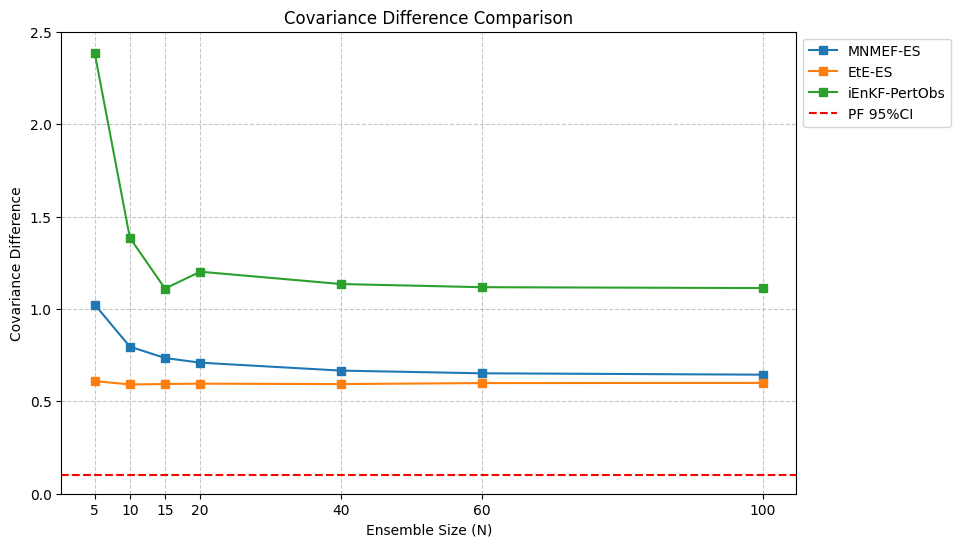

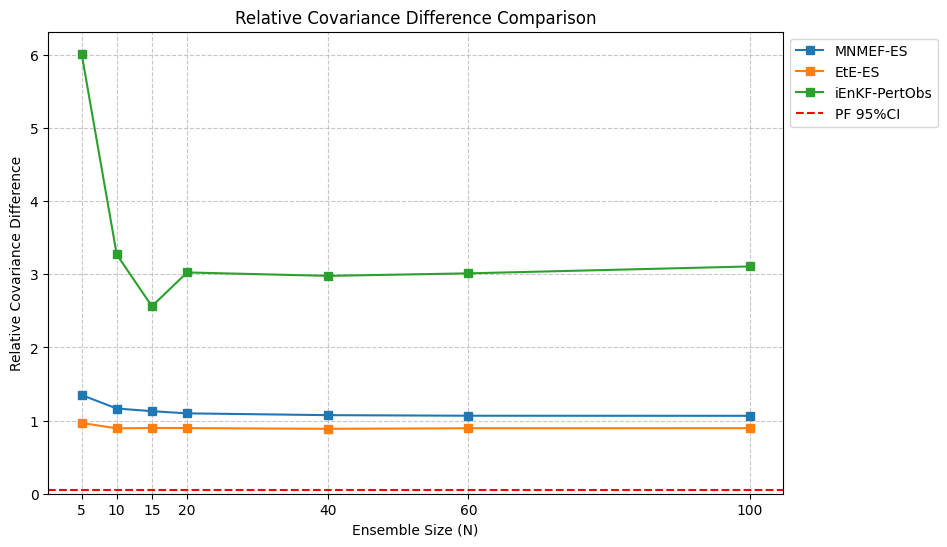

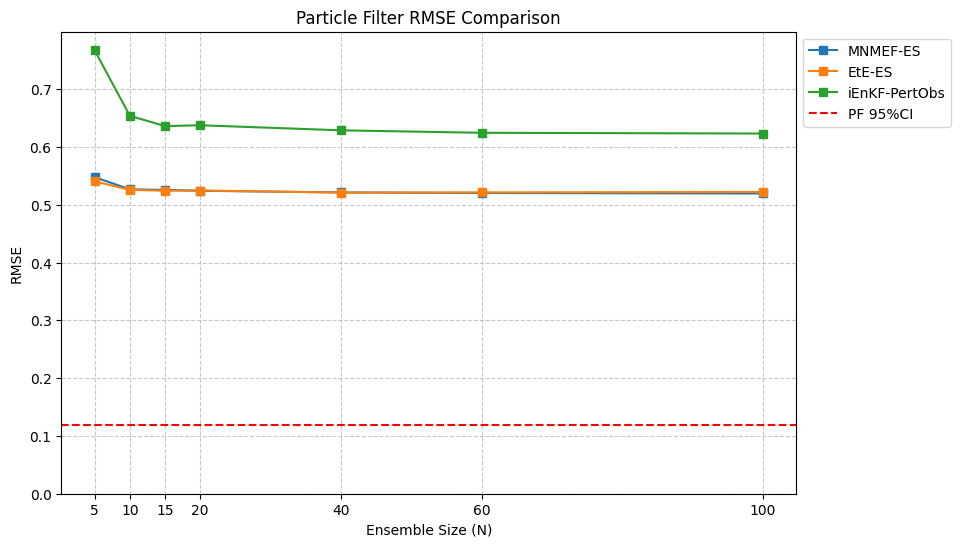

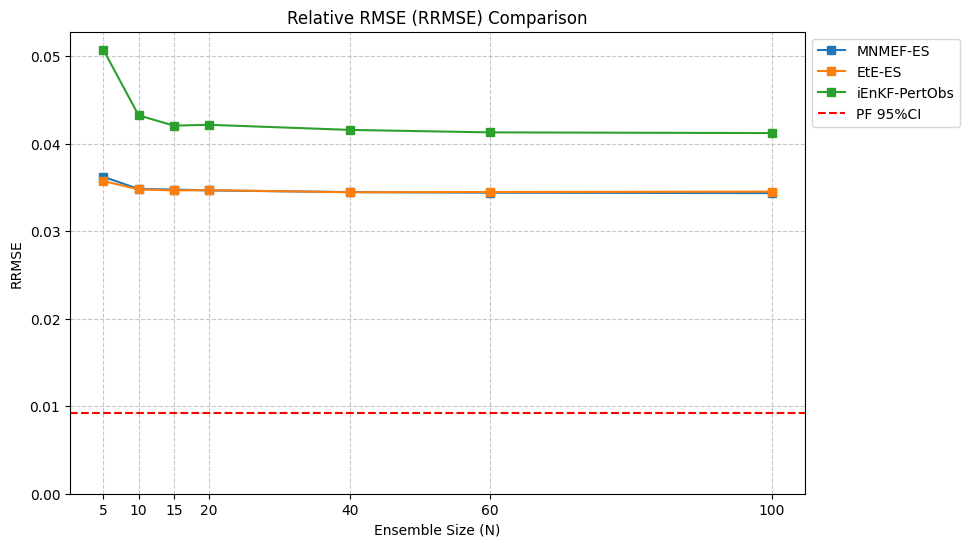

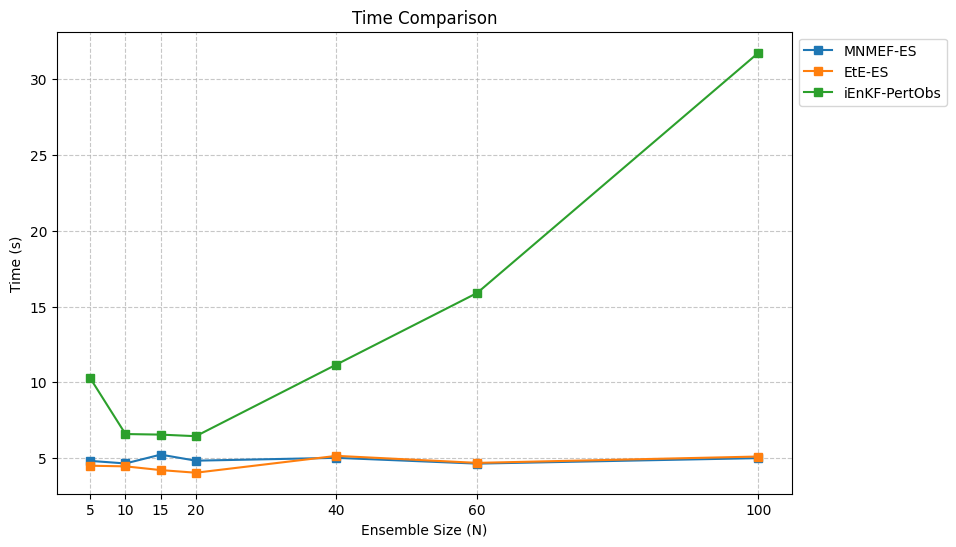

In [7]:
import os
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

# --- [DATA LOADING AND PREPARATION - UNCHANGED EXCEPT NEW METRICS] ---
PF_RMSE_95CI = 0.119728
PF_Cov_Diff_95CI = 0.10073
PF_RRMSE_95CI = 0.00927624
PF_RCov_Diff_95CI = 0.0572706
ensemble_sizes = [5, 10, 15, 20, 40, 60, 100]

data_folders = [
    "2025-06-28_21-55lorenz63_1.0_10_60_8192_es_joint_CorrTerms",
    "lorenz63_EtE_LRes/2025-07-09_19-08lorenz63_1.0_10_60_8192_es_joint_EtE-LRes_nst",
    # "lorenz63_EtE_LRes/2025-08-08_09-55lorenz63_1.0_20_60_8192_nl2_joint_EtE-LRes_nst_tuned",
    "lorenz63_benchmarks/benchmark_lorenz63_1.0_iEnKS-PertObs",
]

method_names = [
    'MNMEF-ES',
    'EtE-ES',        # always nst
    # 'EtE-ES-FT',
    "iEnKF-PertObs",
]

results = {}

num_sizes = len(ensemble_sizes)
for i, folder in enumerate(data_folders):
    for ens_size in ensemble_sizes:
        filename = f"output_records_{ens_size}.pt"
        method_name = method_names[i]
        data_file = os.path.join("save", folder, filename)

        # Load file
        data = torch.load(data_file, weights_only=True)

        # Required metrics
        cov_diff = data["nn"]['cov_diff']
        pf_rmse = data["nn"]['pf_rmse']
        t = data["time"]

        # Optional relative metrics (preferred if present)
        rrmse = data["nn"].get('pf_rrmse', float('nan'))
        rcov_diff = data["nn"].get('rcov_diff', float('nan'))

        # Initialize buckets
        results.setdefault(method_name, {})
        for key in ['cov_diff', 'pf_rmse', 'rrmse', 'rcov_diff', 'time']:
            results[method_name].setdefault(key, [])

        # Append metrics
        results[method_name]['cov_diff'].append(cov_diff)
        results[method_name]['pf_rmse'].append(pf_rmse)
        results[method_name]['rrmse'].append(rrmse)
        results[method_name]['rcov_diff'].append(rcov_diff)
        results[method_name]['time'].append(t)

# --- Figure 1: Covariance Difference ---
fig1, ax1 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax1.plot(ensemble_sizes, results[key]['cov_diff'], marker='s', label=key)
ax1.axhline(y=PF_Cov_Diff_95CI, color='r', linestyle='--', label='PF 95%CI')
ax1.set_title('Covariance Difference Comparison')
ax1.set_xlabel('Ensemble Size (N)')
ax1.set_ylabel('Covariance Difference')
ax1.set_xticks(ensemble_sizes)
ax1.set_ylim(bottom=0)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig1.subplots_adjust(right=0.65)

# --- Figure 2: Relative Covariance Difference (NEW) ---
# NOTE: Per request, ax4 -> ax2
fig4, ax2 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax2.plot(ensemble_sizes, results[key]['rcov_diff'], marker='s', label=key)
ax2.axhline(y=PF_RCov_Diff_95CI, color='r', linestyle='--', label='PF 95%CI')
ax2.set_title('Relative Covariance Difference Comparison')
ax2.set_xlabel('Ensemble Size (N)')
ax2.set_ylabel('Relative Covariance Difference')
ax2.set_xticks(ensemble_sizes)
ax2.set_ylim(bottom=0)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig4.subplots_adjust(right=0.65)

# --- Figure 2: Particle Filter RMSE ---
# NOTE: Per request, ax2 -> ax4
fig2, ax4 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax4.plot(ensemble_sizes, results[key]['pf_rmse'], marker='s', label=key)
ax4.axhline(y=PF_RMSE_95CI, color='r', linestyle='--', label='PF 95%CI')
ax4.set_title('Particle Filter RMSE Comparison')
ax4.set_xlabel('Ensemble Size (N)')
ax4.set_ylabel('RMSE')
ax4.set_xticks(ensemble_sizes)
ax4.set_ylim(bottom=0)
ax4.grid(True, linestyle='--', alpha=0.7)
ax4.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig2.subplots_adjust(right=0.65)

# --- Figure 3: Relative RMSE (NEW) ---
fig3, ax3 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax3.plot(ensemble_sizes, results[key]['rrmse'], marker='s', label=key)
ax3.axhline(y=PF_RRMSE_95CI, color='r', linestyle='--', label='PF 95%CI')
ax3.set_title('Relative RMSE (RRMSE) Comparison')
ax3.set_xlabel('Ensemble Size (N)')
ax3.set_ylabel('RRMSE')
ax3.set_xticks(ensemble_sizes)
ax3.set_ylim(bottom=0)
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig3.subplots_adjust(right=0.65)

# --- Figure 5: Time ---
fig5, ax5 = plt.subplots(figsize=(14, 6))
for key in results.keys():
    ax5.plot(ensemble_sizes, results[key]['time'], marker='s', label=key)
ax5.set_title('Time Comparison')
ax5.set_xlabel('Ensemble Size (N)')
ax5.set_ylabel('Time (s)')
ax5.set_xticks(ensemble_sizes)
ax5.grid(True, linestyle='--', alpha=0.7)
ax5.legend(loc='upper left', bbox_to_anchor=(1, 1))
fig5.subplots_adjust(right=0.65)

# Show all plots
plt.show()
